# Baseline Holt-Winters 2025H1 (Benchmark)

This notebook runs a Holt-Winters benchmark per zone on top-demand zones.

Notes:
- Data extraction from HDFS is distributed by Spark.
- Model fitting itself is done in pandas/statsmodels on driver as a benchmark.
- Outputs are written back to HDFS.

In [1]:
import json
import subprocess
import sys
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, functions as F

try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels"])
    from statsmodels.tsa.holtwinters import ExponentialSmoothing

spark = (
    SparkSession.builder
    .appName("DemandPredictionHoltWintersBenchmark2025H1")
    .master("spark://master:7077")
    .config("spark.driver.memory", "2g")
    .config("spark.executor.memory", "2g")
    .config("spark.eventLog.enabled", "true")
    .config("spark.eventLog.dir", "hdfs://master:9000/spark-logs")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

def cluster_util(stage_name):
    print(f"\n===== CLUSTER UTILIZATION: {stage_name} =====")
    try:
        payload = json.load(urllib.request.urlopen("http://master:8080/json/"))
        workers = payload.get("workers", [])
        print("alive workers:", payload.get("aliveworkers"))
        print("active apps :", len(payload.get("activeapps", [])))
        for w in workers:
            print("worker", w.get("id"), "cores", f"{w.get('coresused', 0)}/{w.get('cores', 0)}", "memory", f"{w.get('memoryused', 0)}/{w.get('memory', 0)}")
    except Exception as e:
        print("Could not query Spark Master JSON:", e)

cluster_util("session_started")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 100.0 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 387.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 KB 401.1 kB/s eta 0:00:00


:: loading settings :: url = jar:file:/opt/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
graphframes#graphframes added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-ecb3bda0-ec03-46db-bd0b-1ed5a88e8754;1.0
	confs: [default]
	found graphframes#graphframes;0.8.3-spark3.5-s_2.12 in spark-packages
	found org.slf4j#slf4j-api;1.7.16 in central
:: resolution report :: resolve 146ms :: artifacts dl 5ms
	:: modules in use:
	graphframes#graphframes;0.8.3-spark3.5-s_2.12 from spark-packages in [default]
	org.slf4j#slf4j-api;1.7.16 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   2   |   0   |   0   |   0   ||   2   |   0   |
	-----------------------------------------------


===== CLUSTER UTILIZATION: session_started =====
alive workers: 2
active apps : 1
worker worker-20260403000927-172.18.0.3-7078 cores 2/2 memory 2048/2048
worker worker-20260403000927-172.18.0.4-7078 cores 2/2 memory 2048/2048


In [3]:
DENSE_PATH = "/user/data/feature_engineering/demand_prediction_2025H1_dense_10m"
OUT_BASE = "/user/data/results/demand_prediction/2025H1_holt_winters"
ZONE_COL = "PULocationID"
BIN_COL = "pickup_bin_10m"
TARGET_COL = "pickup_demand"

# Keep benchmark scope small enough for driver-side statsmodels fitting.
TOP_N_ZONES = 20
SEASONAL_PERIODS = 144
WINDOW_START_TS = "2025-09-01 00:00:00"
WINDOW_END_TS = "2025-12-01 00:00:00"

dense_all = spark.read.parquet(DENSE_PATH)
dense = (
    dense_all
    .where((F.col(BIN_COL) >= F.to_timestamp(F.lit(WINDOW_START_TS))) & (F.col(BIN_COL) < F.to_timestamp(F.lit(WINDOW_END_TS))))
    .select(ZONE_COL, BIN_COL, TARGET_COL)
    .cache()
)

dense_rows = dense.count()
if dense_rows == 0:
    raise ValueError(f"No dense rows in window [{WINDOW_START_TS}, {WINDOW_END_TS}).")
print(f"Dense rows in window [{WINDOW_START_TS}, {WINDOW_END_TS}):", dense_rows)
cluster_util("after_dense_read")

top_zones = [
    r[ZONE_COL]
    for r in dense.groupBy(ZONE_COL)
    .agg(F.sum(TARGET_COL).alias("total"))
    .orderBy(F.col("total").desc())
    .limit(TOP_N_ZONES)
    .collect()
]

print("Top zones selected:", len(top_zones))
pdf = (
    dense.where(F.col(ZONE_COL).isin(top_zones))
    .orderBy(ZONE_COL, BIN_COL)
    .toPandas()
)

pdf[BIN_COL] = pd.to_datetime(pdf[BIN_COL])
pdf[TARGET_COL] = pd.to_numeric(pdf[TARGET_COL], errors="coerce").fillna(0.0)
print("Rows collected to pandas:", len(pdf))
cluster_util("after_collect_top_zones")

Dense rows in window [2025-09-01 00:00:00, 2025-12-01 00:00:00): 3433248

===== CLUSTER UTILIZATION: after_dense_read =====
alive workers: 2
active apps : 1
worker worker-20260403000927-172.18.0.3-7078 cores 2/2 memory 2048/2048
worker worker-20260403000927-172.18.0.4-7078 cores 2/2 memory 2048/2048
Top zones selected: 20
Rows collected to pandas: 262080

===== CLUSTER UTILIZATION: after_collect_top_zones =====
alive workers: 2
active apps : 1
worker worker-20260403000927-172.18.0.3-7078 cores 2/2 memory 2048/2048
worker worker-20260403000927-172.18.0.4-7078 cores 2/2 memory 2048/2048


In [4]:
metrics = []
pred_rows = []

for zone_id, g in pdf.groupby(ZONE_COL):
    g = g.sort_values(BIN_COL).reset_index(drop=True)
    y = g[TARGET_COL].astype(float).to_numpy()

    if len(y) < (SEASONAL_PERIODS * 3):
        continue

    split_idx = int(len(y) * 0.7)
    split_idx = max(split_idx, SEASONAL_PERIODS * 2)
    split_idx = min(split_idx, len(y) - 1)

    y_train = y[:split_idx]
    y_test = y[split_idx:]
    ts_test = g[BIN_COL].iloc[split_idx:].to_numpy()

    try:
        hw = ExponentialSmoothing(
            y_train,
            trend="add",
            seasonal="add",
            seasonal_periods=SEASONAL_PERIODS,
            initialization_method="estimated",
        )
        fitted = hw.fit(optimized=True)
        pred = fitted.forecast(len(y_test))
    except Exception:
        continue

    pred = np.maximum(np.asarray(pred, dtype=float), 0.0)
    mae = float(np.mean(np.abs(y_test - pred)))
    rmse = float(np.sqrt(np.mean((y_test - pred) ** 2)))
    mask = y_test > 0
    mape = float(np.mean(np.abs((y_test[mask] - pred[mask]) / y_test[mask])) * 100.0) if mask.any() else None

    metrics.append({
        ZONE_COL: int(zone_id),
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
    })

    pred_rows.extend([
        {
            ZONE_COL: int(zone_id),
            BIN_COL: ts_test[i],
            "actual": float(y_test[i]),
            "prediction": float(pred[i]),
        }
        for i in range(len(y_test))
    ])

metrics_pdf = pd.DataFrame(metrics)
pred_pdf = pd.DataFrame(pred_rows)

if len(metrics_pdf) == 0:
    raise ValueError("No zone produced a valid Holt-Winters fit.")

display(metrics_pdf.sort_values("MAPE"))
print("Avg MAPE across fitted zones:", metrics_pdf["MAPE"].dropna().mean())

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_

,PULocationID,MAE,RMSE,MAPE,n_train,n_test
19,249,15.911101,23.650484,92.879815,9172,3932
2,79,13.801351,25.258612,98.289125,9172,3932
6,141,17.394969,21.392451,133.652436,9172,3932
7,142,23.309910,30.092285,190.149376,9172,3932
14,230,16.654736,20.402136,227.245394,9172,3932
9,162,16.396810,20.525402,232.440711,9172,3932
3,107,14.158197,16.724487,270.818178,9172,3932
11,164,14.548528,17.264487,296.152676,9172,3932
13,186,23.859549,28.609804,349.995487,9172,3932
1,68,19.499214,23.203439,360.100434,9172,3932


Avg MAPE across fitted zones: 3733.4132215796803


In [5]:
metrics_sdf = spark.createDataFrame(metrics_pdf)
pred_sdf = spark.createDataFrame(pred_pdf)

metrics_sdf.write.mode("overwrite").parquet(f"{OUT_BASE}/metrics")
pred_sdf.write.mode("overwrite").parquet(f"{OUT_BASE}/predictions")

print("Saved outputs:")
print(f"- {OUT_BASE}/metrics")
print(f"- {OUT_BASE}/predictions")
cluster_util("after_hw_write")

Saved outputs:
- /user/data/results/demand_prediction/2025H1_holt_winters/metrics
- /user/data/results/demand_prediction/2025H1_holt_winters/predictions

===== CLUSTER UTILIZATION: after_hw_write =====
alive workers: 2
active apps : 1
worker worker-20260403000927-172.18.0.3-7078 cores 2/2 memory 2048/2048
worker worker-20260403000927-172.18.0.4-7078 cores 2/2 memory 2048/2048


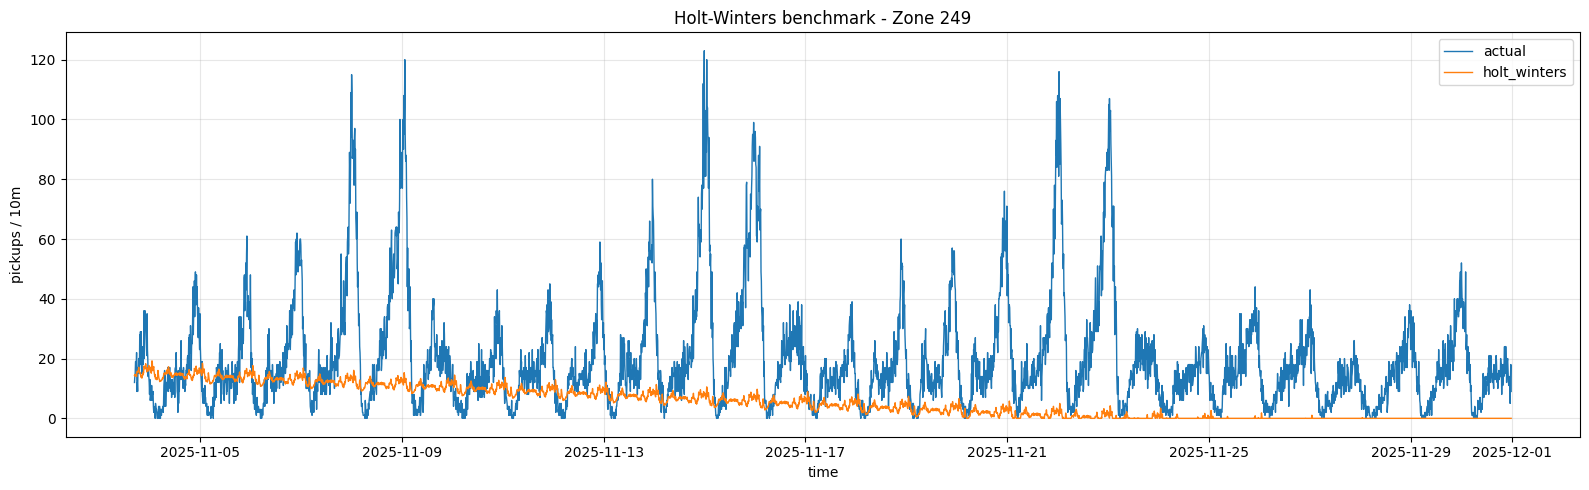

In [6]:
best_zone = int(metrics_pdf.sort_values("MAPE").iloc[0][ZONE_COL])
tmp = pred_pdf[pred_pdf[ZONE_COL] == best_zone].copy().sort_values(BIN_COL)

plt.figure(figsize=(16, 5))
plt.plot(tmp[BIN_COL], tmp["actual"], label="actual", linewidth=1.0)
plt.plot(tmp[BIN_COL], tmp["prediction"], label="holt_winters", linewidth=1.0)
plt.title(f"Holt-Winters benchmark - Zone {best_zone}")
plt.xlabel("time")
plt.ylabel("pickups / 10m")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()